# Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# How to read data

In [3]:
df=pd.read_csv(r"C:\Users\Niranjan\Downloads\dirty_cafe_sales.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


# Handle NaN values

In [5]:
df.isna().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [6]:
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

# Show Datatypes & change Datatypes

In [7]:
df.dtypes

Transaction ID      object
Item                object
Quantity            object
Price Per Unit      object
Total Spent         object
Payment Method      object
Location            object
Transaction Date    object
dtype: object

In [8]:
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"],errors="coerce")

In [9]:
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["Price Per Unit"] = pd.to_numeric(df["Price Per Unit"], errors="coerce")
df["Total Spent"] = pd.to_numeric(df["Total Spent"], errors="coerce")

In [10]:
df.fillna(0, inplace=True)

In [11]:
df.dtypes

Transaction ID       object
Item                 object
Quantity            float64
Price Per Unit      float64
Total Spent         float64
Payment Method       object
Location             object
Transaction Date     object
dtype: object

In [12]:
df.columns = df.columns.str.strip()

In [13]:
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], errors="coerce")

In [14]:
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], format="%d-%m-%Y", errors="coerce")

In [15]:
df["Transaction Date"].dtype

dtype('<M8[ns]')

In [16]:
df.dtypes

Transaction ID              object
Item                        object
Quantity                   float64
Price Per Unit             float64
Total Spent                float64
Payment Method              object
Location                    object
Transaction Date    datetime64[ns]
dtype: object

In [17]:
df.dropna(inplace=True)

In [18]:
df.fillna("Unknown", inplace=True)

In [19]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [20]:
df.isna().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

# Handle missing value

In [21]:
for i in df:
    print("===================================")
    print(df[i].value_counts())

Transaction ID
TXN_1961373    1
TXN_4977031    1
TXN_4271903    1
TXN_7034554    1
TXN_3160411    1
              ..
TXN_7672686    1
TXN_9659401    1
TXN_5255387    1
TXN_7695629    1
TXN_6170729    1
Name: count, Length: 10000, dtype: int64
Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
UNKNOWN      344
0            333
ERROR        292
Name: count, dtype: int64
Quantity
5.0    2013
2.0    1974
4.0    1863
3.0    1849
1.0    1822
0.0     479
Name: count, dtype: int64
Price Per Unit
3.0    2429
4.0    2331
2.0    1227
5.0    1204
1.0    1143
1.5    1133
0.0     533
Name: count, dtype: int64
Total Spent
6.0     979
12.0    939
3.0     930
4.0     923
20.0    746
15.0    734
8.0     677
10.0    524
0.0     502
2.0     497
9.0     479
5.0     468
16.0    444
25.0    259
7.5     237
1.0     232
4.5     225
1.5     205
Name: count, dtype: int64
Payment Method
0                 2579
Digital Wallet 

In [22]:
df.replace(["ERROR", "UNKNOWN"], pd.NA, inplace=True)

In [23]:
df.isna().sum()

Transaction ID        0
Item                636
Quantity              0
Price Per Unit        0
Total Spent           0
Payment Method      599
Location            696
Transaction Date      0
dtype: int64

In [24]:
df["Item"].fillna(df["Item"].mode()[0], inplace=True)
df["Location"].fillna(df["Location"].mode()[0], inplace=True)
df["Payment Method"].fillna(df["Payment Method"].mode()[0], inplace=True)

In [25]:
df.isna().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

In [26]:
for i in df:
    print("===================================")
    print(df[i].value_counts())

Transaction ID
TXN_1961373    1
TXN_4977031    1
TXN_4271903    1
TXN_7034554    1
TXN_3160411    1
              ..
TXN_7672686    1
TXN_9659401    1
TXN_5255387    1
TXN_7695629    1
TXN_6170729    1
Name: count, Length: 10000, dtype: int64
Item
Juice       1807
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
0            333
Name: count, dtype: int64
Quantity
5.0    2013
2.0    1974
4.0    1863
3.0    1849
1.0    1822
0.0     479
Name: count, dtype: int64
Price Per Unit
3.0    2429
4.0    2331
2.0    1227
5.0    1204
1.0    1143
1.5    1133
0.0     533
Name: count, dtype: int64
Total Spent
6.0     979
12.0    939
3.0     930
4.0     923
20.0    746
15.0    734
8.0     677
10.0    524
0.0     502
2.0     497
9.0     479
5.0     468
16.0    444
25.0    259
7.5     237
1.0     232
4.5     225
1.5     205
Name: count, dtype: int64
Payment Method
0                 3178
Digital Wallet    2291
Credit Card       2273
Cas

# Show Datatypes

In [27]:
num_col=df.select_dtypes(include=('int64','float64'))

In [28]:
num_col

,Quantity,Price Per Unit,Total Spent
0,2.0,2.0,4.0
1,4.0,3.0,12.0
2,4.0,1.0,0.0
3,2.0,5.0,10.0
4,2.0,2.0,4.0
...,...,...,...
9995,2.0,2.0,4.0
9996,3.0,0.0,3.0
9997,4.0,2.0,8.0
9998,3.0,0.0,3.0


In [29]:
obj_col=df.select_dtypes(include=('object'))

In [30]:
obj_col

,Transaction ID,Item,Payment Method,Location
0,TXN_1961373,Coffee,Credit Card,Takeaway
1,TXN_4977031,Cake,Cash,In-store
2,TXN_4271903,Cookie,Credit Card,In-store
3,TXN_7034554,Salad,0,0
4,TXN_3160411,Coffee,Digital Wallet,In-store
...,...,...,...,...
9995,TXN_7672686,Coffee,0,0
9996,TXN_9659401,0,Digital Wallet,0
9997,TXN_5255387,Coffee,Digital Wallet,0
9998,TXN_7695629,Cookie,Digital Wallet,0


# Statistic of cols

In [31]:
df.describe()

,Quantity,Price Per Unit,Total Spent,Transaction Date
count,10000.000000,10000.000000,10000.000000,10000
mean,2.883400,2.792750,8.476350,2021-01-14 02:53:39.840000
min,0.000000,0.000000,0.000000,1970-01-01 00:00:00
25%,2.000000,1.500000,4.000000,2023-03-19 00:00:00
50%,3.000000,3.000000,7.500000,2023-06-24 00:00:00
75%,4.000000,4.000000,12.000000,2023-09-27 00:00:00
max,5.000000,5.000000,25.000000,2023-12-31 00:00:00
std,1.528214,1.409422,6.172809,NaN


In [32]:
df.describe(include=('object'))

,Transaction ID,Item,Payment Method,Location
count,10000,10000,10000,10000
unique,10000,9,4,3
top,TXN_1961373,Juice,0,0
freq,1,1807,3178,3961


# Unique and Duplicated values

In [33]:
for i in df:
    print("====================================")
    print(i)
    print(df[i].unique())

Transaction ID
['TXN_1961373' 'TXN_4977031' 'TXN_4271903' ... 'TXN_5255387' 'TXN_7695629'
 'TXN_6170729']
Item
['Coffee' 'Cake' 'Cookie' 'Salad' 'Smoothie' 'Juice' 'Sandwich' 0 'Tea']
Quantity
[2. 4. 5. 3. 1. 0.]
Price Per Unit
[2.  3.  1.  5.  4.  1.5 0. ]
Total Spent
[ 4.  12.   0.  10.  20.   9.  16.  15.  25.   8.   5.   3.   6.   2.
  1.   7.5  4.5  1.5]
Payment Method
['Credit Card' 'Cash' 0 'Digital Wallet']
Location
['Takeaway' 'In-store' 0]
Transaction Date
<DatetimeArray>
['2023-09-08 00:00:00', '2023-05-16 00:00:00', '2023-07-19 00:00:00',
 '2023-04-27 00:00:00', '2023-06-11 00:00:00', '2023-03-31 00:00:00',
 '2023-10-06 00:00:00', '2023-10-28 00:00:00', '2023-07-28 00:00:00',
 '2023-12-31 00:00:00',
 ...
 '2023-08-01 00:00:00', '2023-01-20 00:00:00', '2023-11-11 00:00:00',
 '2023-02-13 00:00:00', '2023-07-30 00:00:00', '2023-02-17 00:00:00',
 '2023-05-20 00:00:00', '2023-11-05 00:00:00', '2023-03-27 00:00:00',
 '2023-07-03 00:00:00']
Length: 366, dtype: datetime64[ns]


In [34]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool

In [35]:
df.duplicated().sum()

np.int64(0)

# Check shape

In [36]:
df.shape

(10000, 8)

# Range Slicing using iloc

In [37]:
X = df.iloc[:,1:]

In [38]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Item              10000 non-null  object        
 1   Quantity          10000 non-null  float64       
 2   Price Per Unit    10000 non-null  float64       
 3   Total Spent       10000 non-null  float64       
 4   Payment Method    10000 non-null  object        
 5   Location          10000 non-null  object        
 6   Transaction Date  10000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 547.0+ KB


In [62]:
y=df.iloc[:,-4]

In [63]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 10000 entries, 0 to 9999
Series name: Total Spent
Non-Null Count  Dtype  
--------------  -----  
10000 non-null  float64
dtypes: float64(1)
memory usage: 78.3 KB


# Drop cols

In [64]:
df.drop("Transaction ID", axis=1, inplace=True)

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Item              10000 non-null  object        
 1   Quantity          10000 non-null  float64       
 2   Price Per Unit    10000 non-null  float64       
 3   Total Spent       10000 non-null  float64       
 4   Payment Method    10000 non-null  object        
 5   Location          10000 non-null  object        
 6   Transaction Date  10000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 547.0+ KB


# For loop with list,dataframe

In [43]:
columns = ["Transaction ID","Item","Quantity","Price Per Unit","Total Spent","Payment Method","Location","Transaction Date"]

In [44]:
for col in columns:
    print(col)

Transaction ID
Item
Quantity
Price Per Unit
Total Spent
Payment Method
Location
Transaction Date


In [67]:
for col in df.columns:
    print(col, df[col].dtype)

Item object
Quantity float64
Price Per Unit float64
Total Spent float64
Payment Method object
Location object
Transaction Date datetime64[ns]


In [66]:
for i, col in enumerate(df.columns):
    print(i, col)

0 Item
1 Quantity
2 Price Per Unit
3 Total Spent
4 Payment Method
5 Location
6 Transaction Date


# Find Outliers Using Boxplot

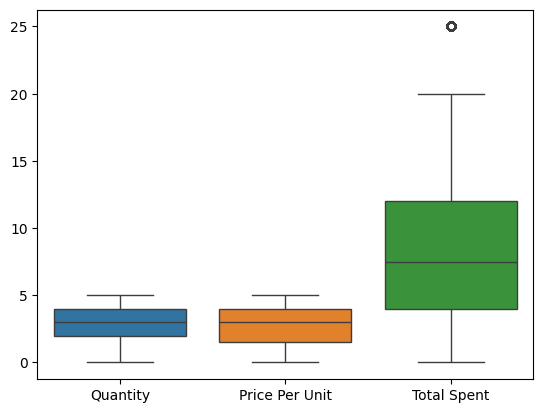

In [48]:
sns.boxplot(data=df)
plt.show()

# Remove Outliers Using IQR Method

In [49]:
df_clean = df.copy()

cols = ["Quantity","Price Per Unit","Total Spent"]

for col in cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

In [50]:
print("Before Outlier Removal:", df.shape)
print("After Outlier Removal:", df_clean.shape)

Before Outlier Removal: (10000, 8)
After Outlier Removal: (9741, 8)


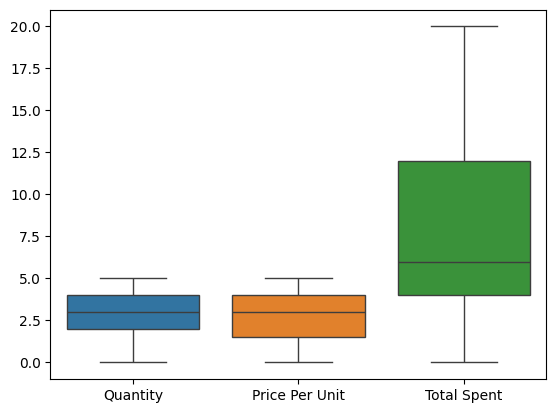

In [51]:
sns.boxplot(data=df_clean)
plt.show()

# Download Excel File 

In [52]:
df_clean.to_excel("clean_data.xlsx", index=False)

In [53]:
print(type(df_clean))

<class 'pandas.core.frame.DataFrame'>


In [54]:
df_clean.to_excel("clean_data.xlsx", index=False)

# Correlation Heatmap

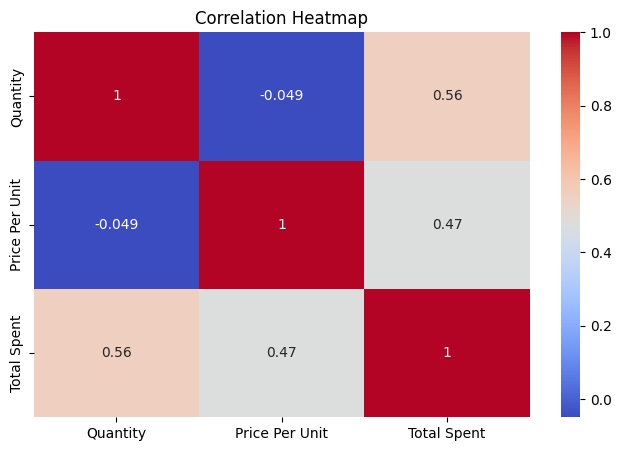

In [55]:
plt.figure(figsize=(8,5))
corr = df_clean.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Barplot

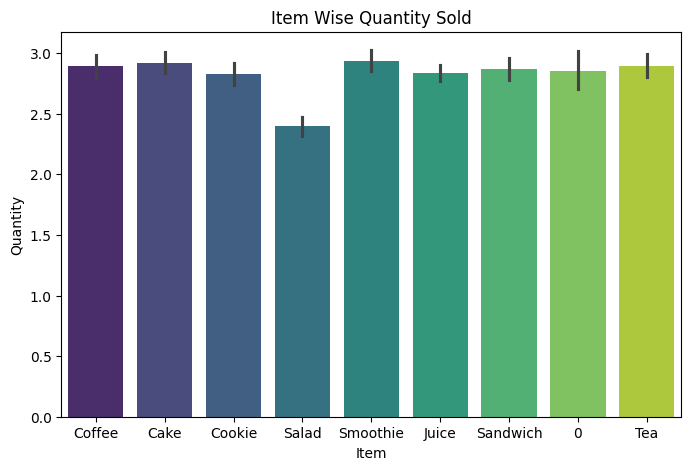

In [69]:
plt.figure(figsize=(8,5))
sns.barplot(x="Item", y="Quantity", data=df_clean, palette="viridis")
plt.title("Item Wise Quantity Sold")
plt.show()

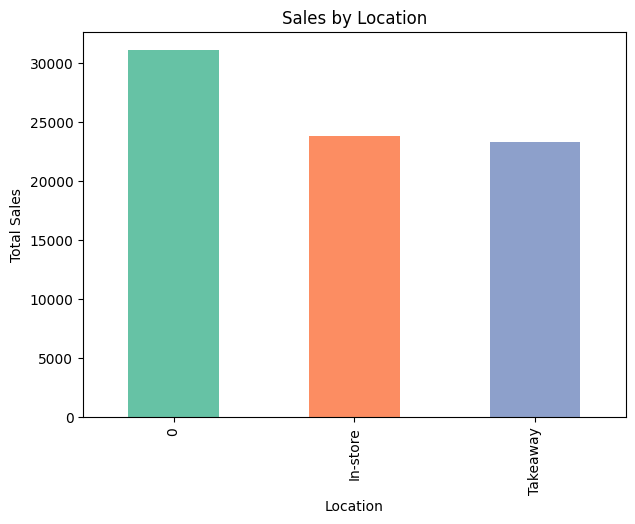

In [57]:
plt.figure(figsize=(7,5))
df_clean.groupby("Location")["Total Spent"].sum().plot(kind="bar",color=sns.color_palette("Set2"))
plt.title("Sales by Location")
plt.xlabel("Location")
plt.ylabel("Total Sales")
plt.show()

# Pie Chart

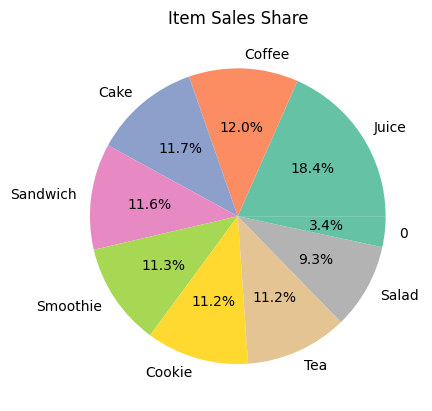

In [58]:
df_clean["Item"].value_counts().plot(kind="pie", autopct="%1.1f%%",colors=sns.color_palette("Set2"))
plt.title("Item Sales Share")
plt.ylabel("")
plt.show()

# Countplot

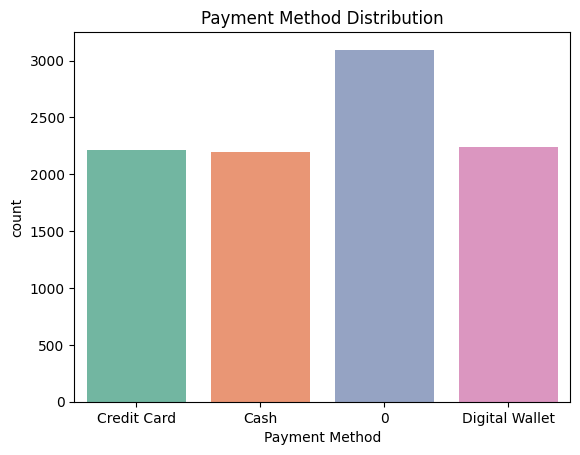

In [59]:
sns.countplot(x="Payment Method", data=df_clean,palette="Set2")
plt.title("Payment Method Distribution")
plt.show()

# Histplot

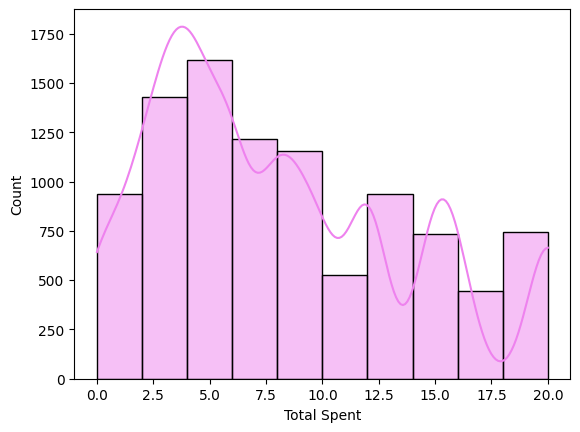

In [60]:
sns.histplot(df_clean['Total Spent'],bins=10,kde=True,color="violet")
plt.show()

# Line Chart

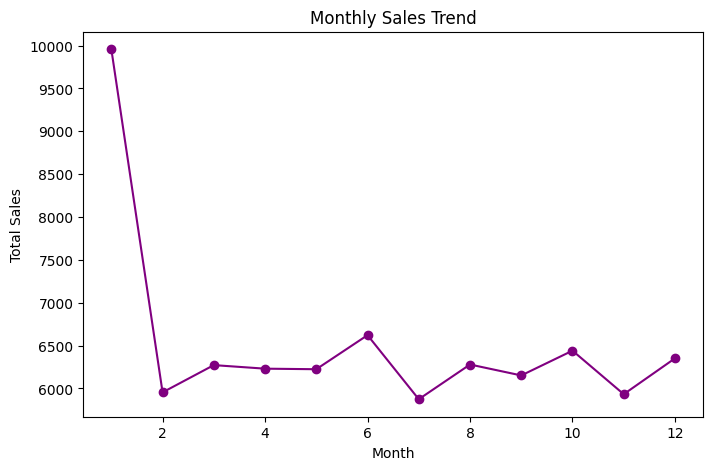

In [61]:
df_clean["Month"] = df_clean["Transaction Date"].dt.month
plt.figure(figsize=(8,5))
df_clean.groupby("Month")["Total Spent"].sum().plot(kind="line",color="purple",marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()